In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

# K-Medoids
from sklearn_extra.cluster import KMedoids

In [15]:
iris = datasets.load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [17]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

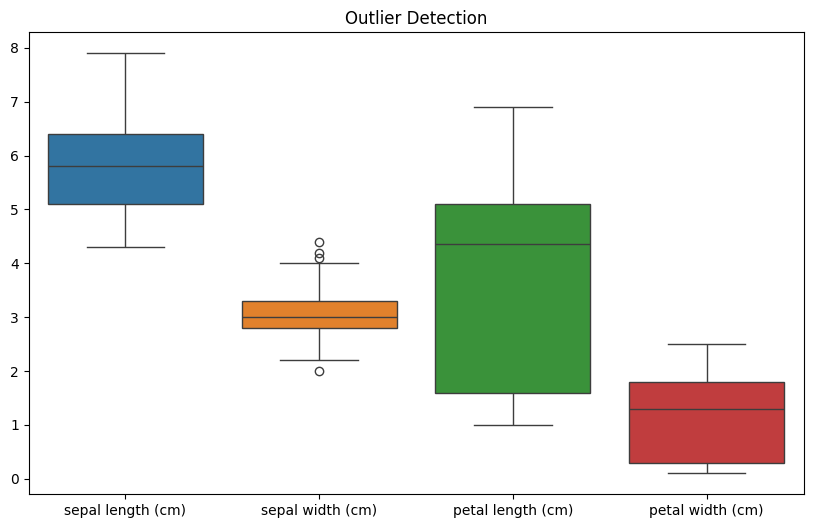

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:, :-1])
plt.title("Outlier Detection")
plt.show()

In [19]:
X = df.iloc[:, :-1]
y = df['target']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

kmeans_silhouette = silhouette_score(X_train_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_train, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("K-Means ARI:", kmeans_ari)

K-Means Silhouette Score: 0.45341242399854614
K-Means ARI: 0.5829946057530989


In [40]:
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids_labels = kmedoids.fit_predict(X_train_scaled)

kmedoids_silhouette = silhouette_score(X_train_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y_train, kmedoids_labels)

print("K-Medoids Silhouette Score:", kmedoids_silhouette)
print("K-Medoids ARI:", kmedoids_ari)

K-Medoids Silhouette Score: 0.4511615686977944
K-Medoids ARI: 0.6044505851166571


In [35]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train_scaled)

mask = dbscan_labels != -1

if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_train_scaled[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = -1

dbscan_ari = adjusted_rand_score(y_train, dbscan_labels)

print("DBSCAN Silhouette Score:", dbscan_silhouette)
print("DBSCAN ARI:", dbscan_ari)

DBSCAN Silhouette Score: 0.595997647818648
DBSCAN ARI: 0.5505288243341354


In [27]:
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids', 'DBSCAN'],
    'Silhouette Score': [kmeans_silhouette, kmedoids_silhouette, dbscan_silhouette],
    'Adjusted Rand Index': [kmeans_ari, kmedoids_ari, dbscan_ari]
})

results

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.453412,0.582995
1,K-Medoids,0.451162,0.604451
2,DBSCAN,0.595998,0.550529


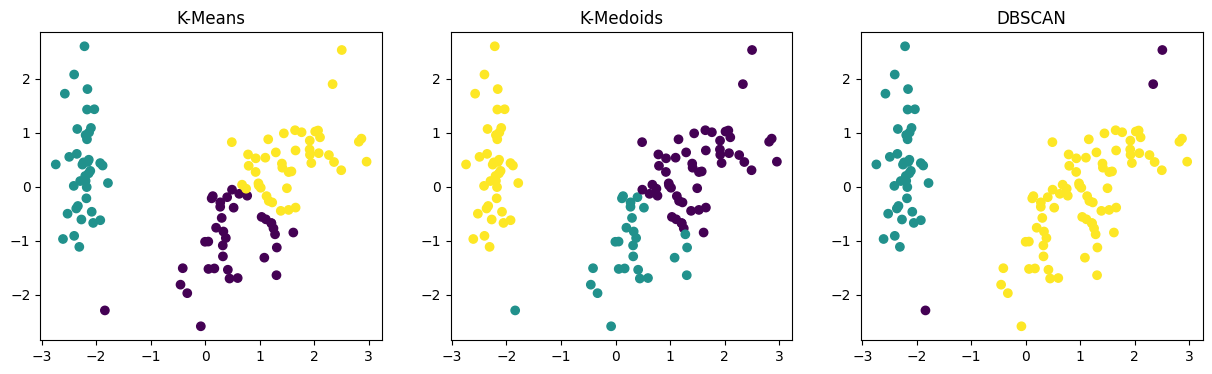

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means")

plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmedoids_labels)
plt.title("K-Medoids")

plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN")

plt.show()